In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)


In [2]:
df = pd.read_csv("../data/raw/dataset_phishing.csv")

X = df.drop(columns=["status", "url"])
y = df["status"].map({"legitimate": 0, "phishing": 1})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (9144, 87)
X_test: (2286, 87)


In [3]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [4]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
y_prob_log = log_reg.predict_proba(X_test_scaled)[:, 1]


/Users/jackedlatino/DataScienceProject-CyberSecurity/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/jackedlatino/DataScienceProject-CyberSecurity/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/jackedlatino/DataScienceProject-CyberSecurity/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/jackedlatino/DataScienceProject-CyberSecurity/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/jackedlatino/DataScienceProject-CyberSecurity/.venv/lib/python3.9/site-p

In [5]:
print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_log))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_log))


Logistic Regression Results
Accuracy: 0.9361329833770778
Precision: 0.9392070484581497
Recall: 0.9326334208223972
F1 Score: 0.935908691834943
ROC-AUC: 0.9814221603751849

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.94      0.94      1143
           1       0.94      0.93      0.94      1143

    accuracy                           0.94      2286
   macro avg       0.94      0.94      0.94      2286
weighted avg       0.94      0.94      0.94      2286



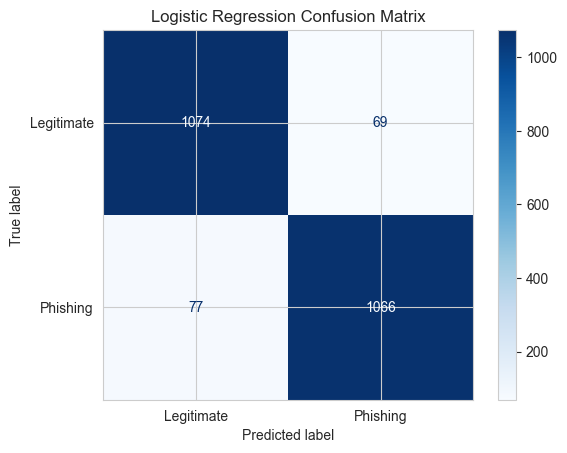

In [6]:
cm = confusion_matrix(y_test, y_pred_log)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.show()


In [ ]:
print("Any +inf or -inf in X_train?", np.isinf(X_train.to_numpy()).any())
print("Any +inf or -inf in X_test?", np.isinf(X_test.to_numpy()).any())
constant_cols = [col for col in X_train.columns if X_train[col].nunique() == 1]
print("Constant columns:", constant_cols)
print("Number of constant columns:", len(constant_cols))
max_values = X_train.abs().max().sort_values(ascending=False)
print(max_values.head(15))


In [8]:
tree_clf = DecisionTreeClassifier(random_state=42, max_depth=5)
tree_clf.fit(X_train, y_train)

y_pred_tree = tree_clf.predict(X_test)
y_prob_tree = tree_clf.predict_proba(X_test)[:, 1]


In [9]:
print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tree))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_tree))


Decision Tree Results
Accuracy: 0.9243219597550306
Precision: 0.9369369369369369
Recall: 0.9098862642169728
F1 Score: 0.9232134931202841
ROC-AUC: 0.9624103198823681

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.94      0.93      1143
           1       0.94      0.91      0.92      1143

    accuracy                           0.92      2286
   macro avg       0.92      0.92      0.92      2286
weighted avg       0.92      0.92      0.92      2286



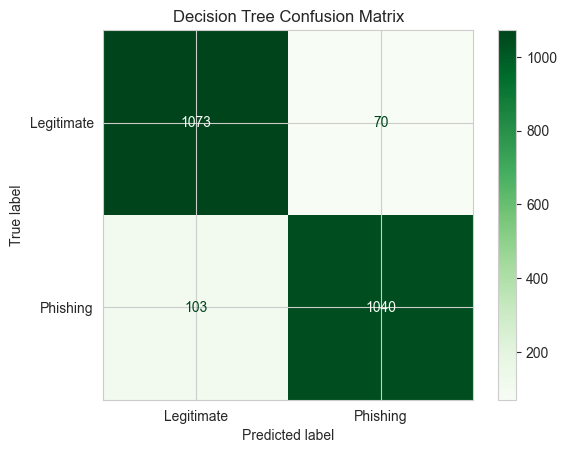

In [10]:
cm = confusion_matrix(y_test, y_pred_tree)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
disp.plot(cmap="Greens")
plt.title("Decision Tree Confusion Matrix")
plt.show()

In [11]:
baseline_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_tree)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_tree)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_tree)
    ]
})

baseline_results


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.936133,0.939207,0.932633,0.935909,0.981422
1,Decision Tree,0.924322,0.936937,0.909886,0.923213,0.962410


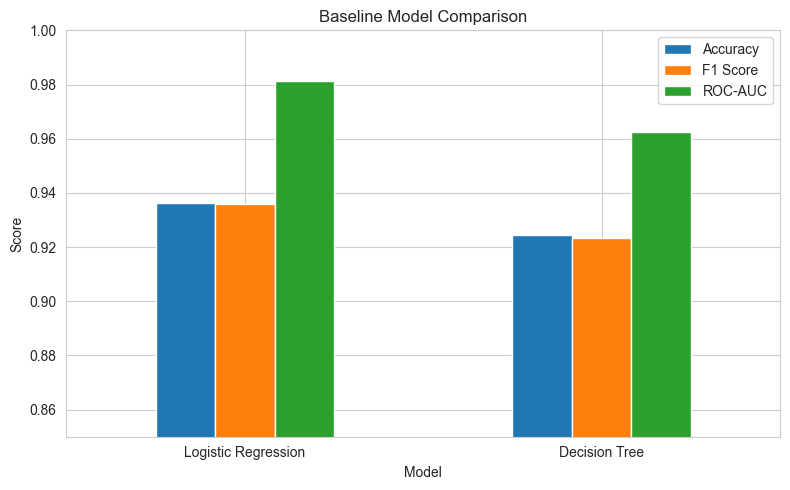

In [12]:
baseline_results.set_index("Model")[["Accuracy", "F1 Score", "ROC-AUC"]].plot(
    kind="bar",
    figsize=(8, 5)
)
plt.title("Baseline Model Comparison")
plt.ylabel("Score")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
